In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "/home/jovyan/sirf-demo/.packages")
import stir_simind_utils as utils
# plotting settings
plt.ion() # interactive 'on' such that plots appear during loops
#%% Import SIRF
import sirf.STIR as spect
import numpy as np
from simind_python_connector import StirSimindAdaptor
import phantomgen as phantom
import numpy as np
import numexpr as ne
ne.set_num_threads(16) # use only 16 threads
from pathlib import Path
demo_path = Path("/home/jovyan/sirf-demo/icf_calculation")


In [17]:
# Define the image grid used for the digital phantoms.
# Both phantoms are generated on a 128 × 128 × 128 grid with isotropic 4.42 mm voxels.
matrix_size = (128,) * 3
voxel_size = (4.42,) * 3

print("Creating Lu-177 uniform cylindrical phantom and attenuation map...")

cyl_act_lu_arr, cyl_ctac_lu_arr, cyl_lu_mask= utils.create_cylindrical_phantom(
    matrix_size=matrix_size,
    voxel_size_mm=voxel_size,
    radius_mm=100,
    length_mm=200,
    activity_concentration_MBq_ml=0.05,
    fill_attenuation_coefficient_cm=0.14,
    perspex_attenuation_coefficient_cm=0.15,
    supersampling=3
)

cyl_act_lu = spect.ImageData()
cyl_act_lu.initialise(dim=matrix_size, vsize=voxel_size)
cyl_act_lu.fill(cyl_act_lu_arr)

source_lu_dir = demo_path / "lu177_128" / "input"
source_lu_dir.mkdir(parents=True, exist_ok=True)

cyl_act_lu.write(str(source_lu_dir / "cyl_lu_act"))

cyl_ctac_lu = cyl_act_lu.clone()
cyl_ctac_lu.fill(cyl_ctac_lu_arr)
cyl_ctac_lu.write(str(source_lu_dir / "cyl_lu_ctac"))

np.save(str(source_lu_dir / "mask_lu"), cyl_lu_mask)

print()

print("Creating Tc-99m uniform cylindrical phantom and attenuation map...")

cyl_act_tc_arr, cyl_ctac_tc_arr, cyl_tc_mask= utils.create_cylindrical_phantom(
    matrix_size=matrix_size,
    voxel_size_mm=voxel_size,
    radius_mm=100,
    length_mm=200,
    activity_concentration_MBq_ml=0.05,
    fill_attenuation_coefficient_cm=0.154,
    perspex_attenuation_coefficient_cm=0.175,
    supersampling=2
)

cyl_act_tc = spect.ImageData()
cyl_act_tc.initialise(dim=matrix_size, vsize=voxel_size)
cyl_act_tc.fill(cyl_act_tc_arr)

source_tc_dir = demo_path / "tc99m_128" / "input"
source_tc_dir.mkdir(parents=True, exist_ok=True)

cyl_act_tc.write(str(source_tc_dir / "cyl_tc_act"))

cyl_ctac_tc = cyl_act_tc.clone()
cyl_ctac_tc.fill(cyl_ctac_tc_arr)
cyl_ctac_tc.write(str(source_tc_dir / "cyl_tc_ctac"))

np.save(str(source_tc_dir / "mask_tc"), cyl_tc_mask)

Creating Lu-177 uniform cylindrical phantom and attenuation map...



Creating Tc-99m uniform cylindrical phantom and attenuation map...


(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': '99m-Tc Activity [MBq]'}>,
        <Axes: title={'center': 'Attenuation Map [cm-1]'}>], dtype=object))

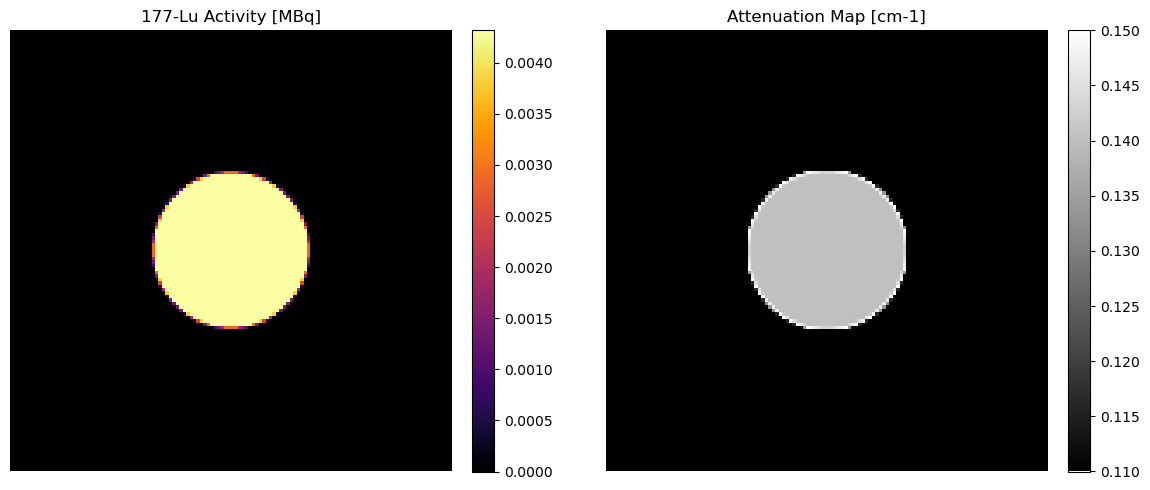

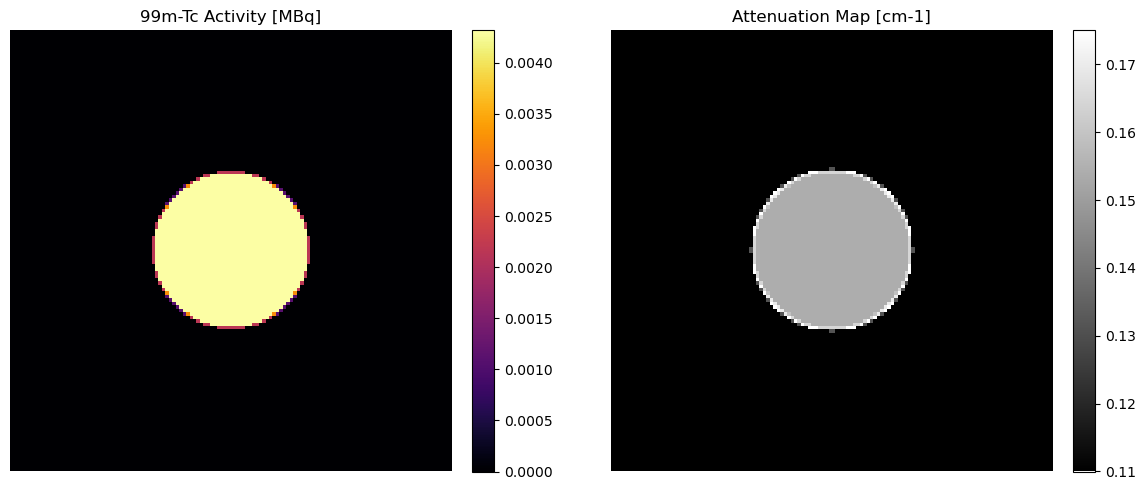

In [18]:
cyl_act_lu = spect.ImageData(str(demo_path / "lu177_128" / "input" / "cyl_lu_act.hv"))
cyl_ctac_lu = spect.ImageData(str(demo_path / "lu177_128" / "input" / "cyl_lu_ctac.hv"))

cyl_act_tc = spect.ImageData(str(demo_path / "tc99m_128/input/cyl_tc_act.hv"))
cyl_ctac_tc = spect.ImageData(str(demo_path / "tc99m_128/input/cyl_tc_ctac.hv"))

cyl_act_lu_arr = cyl_act_lu.as_array()
cyl_ctac_lu_arr = cyl_ctac_lu.as_array()

cyl_act_tc_arr = cyl_act_tc.as_array()
cyl_ctac_tc_arr = cyl_ctac_tc.as_array()

idx = (56,slice(None),slice(None))

utils.display_arr(
    arr_3d=[cyl_act_lu_arr, cyl_ctac_lu_arr],
    idx=idx,
    cmap=["inferno", "gray"],
    vmin=[0, 0.11],
    titles=["177-Lu Activity [MBq]", "Attenuation Map [cm-1]"]
)

utils.display_arr(
    arr_3d=[cyl_act_tc_arr, cyl_ctac_tc_arr],
    idx=idx,
    cmap=["inferno", "gray"],
    vmin=[0, 0.11],
    titles=["99m-Tc Activity [MBq]", "Attenuation Map [cm-1]"]
)

## Simulate Tc-99m SPECT Projection Data with SIMIND

The digital NEMA phantom is now used as input to **SIMIND** to generate simulated SPECT projection data.

The `StirSimindAdaptor` provides an interface between **SIRF/STIR** and **SIMIND**, allowing the activity distribution and attenuation map created previously to be passed directly to the simulation.

For this Tc-99m simulation:

- The **activity image** defines the spatial distribution of the radioactive source.
- The **attenuation map** is used to model photon attenuation within the phantom.
- A **photopeak window** is defined around the 140 keV Tc-99m photopeak.
- An additional **lower-energy scatter window** is generated for subsequent scatter correction.
- The **GE Discovery 670** camera and collimator configuration is specified through the SIMIND configuration.
- A fixed random seed is used to make the simulation reproducible.

SIMIND performs the Monte Carlo simulation and returns the resulting projection data in a form that can subsequently be used by **SIRF/STIR for image reconstruction**.

In [22]:
# for Tc99m

# -------------------------------------------------------------------------
# Define energy window
#
# Example: ±10% photopeak window around 140 keV
# 126–154 keV
#
# scatter_orders = 0 means all scatter orders are accepted by SCATTWIN.
# -------------------------------------------------------------------------

window_lower = [114.0, 126.45]  # 140 - 14 keV
window_upper = [126.0, 154.55]  # 140 + 14 keV
scatter_orders = [0,] * len(window_upper)
time_per_proj = 10 #sec

config_file = Path("/home/jovyan/sirf-demo/.packages/Discovery670_tc99m.yaml")

output_tc_dir = demo_path / "tc99m_128" / "output"
output_tc_dir.mkdir(parents=True, exist_ok=True)

output_prefix = "tc99m_simulation"

simind = StirSimindAdaptor(
    config_source=str(config_file),
    output_dir=str(output_tc_dir),
    output_prefix=output_prefix,
    photon_multiplier=0.01,
)


# Set source and attenuation map

simind.set_source(cyl_act_tc)
simind.set_mu_map(cyl_ctac_tc)

simind.add_config_value(25, np.sum(cyl_act_tc.as_array()) * time_per_proj)

# Set energy windows

simind.set_energy_windows(
    lower_bounds=window_lower,
    upper_bounds=window_upper,
    scatter_orders=scatter_orders,
)


# SIMIND runtime settings

# Tc-99m radionuclide data
simind.add_runtime_switch("FI", "tc99m")

# Discovery 670 collimator.
# Your YAML contains "ge-megp" as text variable 1.
simind.add_runtime_switch("CC", "ge-megp")

# Random seed
simind.add_runtime_switch("RR", 12345)


# -------------------------------------------------------------------------
# Run SIMIND
# -------------------------------------------------------------------------

outputs = simind.run()

INFO: Running SIMIND: simind tc99m_simulation tc99m_simulation /NN:0.01/FI:tc99m/CC:ge-megp/RR:12345/PX:0.4420000076293945


 



              SIMIND Monte Carlo Simulation Program    V8.0  
------------------------------------------------------------------------------
 Phantom S : h2o       Crystal...: nai       InputFile.: tc99m_simulation  
 Phantom B : bone      BackScatt.: pmt       OutputFile: tc99m_simulation  
 Collimator: pb_sb2    SourceRout: smap      SourceImg.: tc99m_simulation_s
 Cover.....: al        ScoreRout.: scattwin  DensityImg: tc99m_simulation_d
------------------------------------------------------------------------------
 PhotonEnergy.......: 140          tc99m     PhotonsPerProj....: 360899         
 EnergyResolution...: 12           Spectra   Activity..........: 3116.4         
 MaxScatterOrder....: 3            ge-megp   DetectorLenght....: 20             
 DetectorWidth......: 27           SPECT     DetectorHeight....: 0.9525         
 UpperEneWindowTresh: 210          x-rays    Distance to det...: 11.942         
 LowerEneWindowTresh: 70           Random    ShiftSource X.....: 0

INFO: Converted 120 radii from orbit file tc99m_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/icf_calculation/tc99m_128/output/tc99m_simulation_air_w1.h00 to /home/jovyan/sirf-demo/icf_calculation/tc99m_128/output/tc99m_simulation_air_w1.hs
INFO: Converted 120 radii from orbit file tc99m_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/icf_calculation/tc99m_128/output/tc99m_simulation_air_w2.h00 to /home/jovyan/sirf-demo/icf_calculation/tc99m_128/output/tc99m_simulation_air_w2.hs
INFO: Converted 120 radii from orbit file tc99m_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/icf_calculation/tc99m_128/output/tc99m_simulation_sca_w1.h00 to /home/jovyan/sirf-demo/icf_calculation/tc99m_128/output/tc99m_simulation_sca_w1.hs
INFO: Converted 120 radii from orbit file tc99m_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/icf_calculation/tc99m_128/output/tc99m_simulation_sca_w2.h00 to /home/jovyan/sirf-demo/icf_calculat

------------------------------------------------------------------------------
 GENERAL DATA
 keV/channel........: 0.5                    CutoffEnergy......: 0              
 Photons/Bq.........: 0.88524                StartingAngle.....: 0              
 CameraOffset X.....: 0                      CoverThickness....: 0.1            
 CameraOffset Y.....: 0                      BackscatterThickn.: 0              
 MatrixSize I.......: 128                    IntrinsicResolut..: 0.55           
 MatrixSize J.......: 128                    AcceptanceAngle...: 4.02754        
 Emission type......: 2                      Initial Weight....: 7644.15096     
 NN ScalingFactor...: 0.01                   Energy Channels...: 512            
                                                                              
 SPECT DATA
 RotationMode.......: 360                    Nr of Projections.: 120            
 RotationAngle......: 3                      Projection.[start]: 1              
 Orbit

In [23]:
output_tc_dir = Path(str(demo_path / "tc99m_128" / "output"))
output_prefix = "tc99m_simulation"

pp_path = output_tc_dir / f"{output_prefix}_tot_w2.hs"
sc_path = output_tc_dir / f"{output_prefix}_tot_w1.hs"

tomo_tc_dir = demo_path / "tc99m_128" / "tomo"
tomo_tc_dir.mkdir(parents=True, exist_ok=True)

pp_path_noisy = tomo_tc_dir / f"{output_prefix}_em_noisy.hs"
sc_path_noisy = tomo_tc_dir / f"{output_prefix}_sc_noisy.hs"
dew_path = tomo_tc_dir / f"{output_prefix}_dew.hs"
dew_sc_path = tomo_tc_dir / f"{output_prefix}_dew_scatter.hs"

utils.acq_poisson_noise(
    hs_file=pp_path,
    save_path=pp_path_noisy
)

utils.acq_poisson_noise(
    hs_file=sc_path,
    save_path=sc_path_noisy
)

acq_dew_cor, dew_scatter = utils.scatter_correction(
    PP_hdr=str(pp_path_noisy),
    SC1_hdr=str(sc_path_noisy),
    save_filepath=dew_path
)

Photopeak window width: 28.1
Scatter window width: 12.0
Scatter fraction: 1.17
Tag !image duration (sec)[1] not found!
Scatter correction completed successfully!


## Visualise the Simulated Projection Data

The simulated SPECT projection data are inspected before proceeding to image reconstruction.

For the **photopeak (EM)** and **scatter (SC)** energy windows, the original SIMIND projections are displayed alongside the corresponding projections after the addition of **Poisson noise**. The same intensity scale is used for each pair to allow direct visual comparison.

The resulting **dual-energy window (DEW) scatter-corrected** projections are also displayed.

This allows us to visually assess the effect of **counting statistics** and **scatter correction** on the projection data that will be used for reconstruction.

(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': 'Tc99m Dual Energy Window corrected'}>,
        <Axes: title={'center': 'Tc99m Dual Energy Window scatter'}>],
       dtype=object))

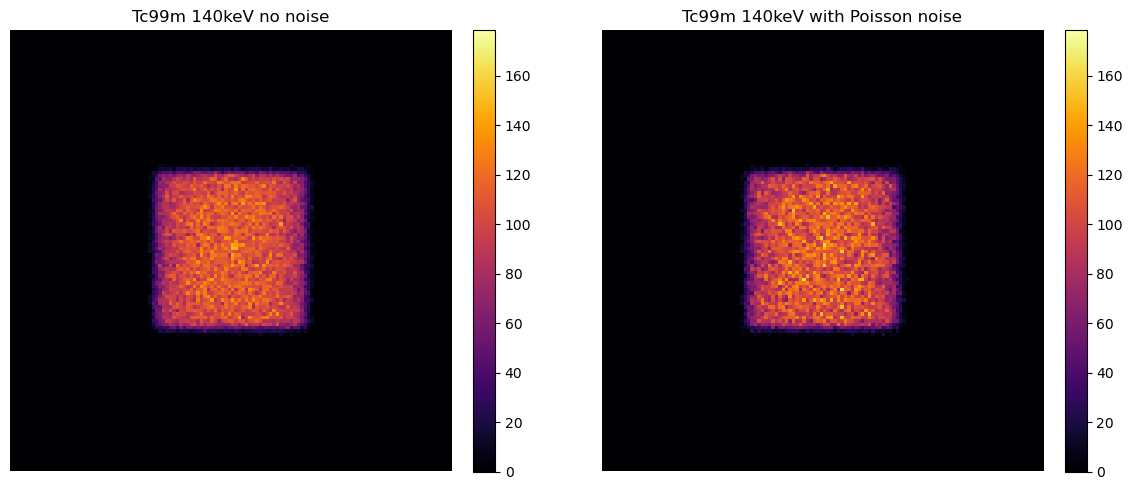

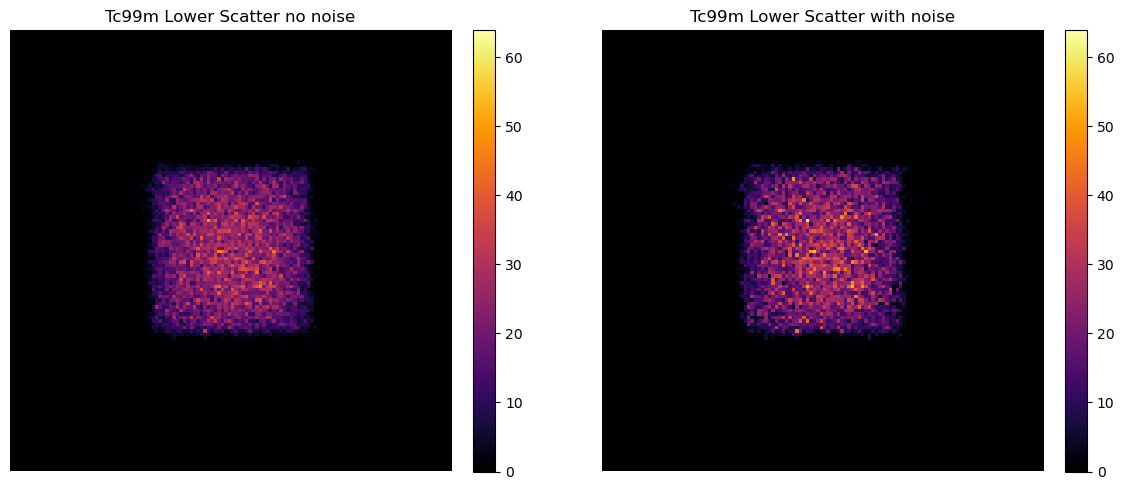

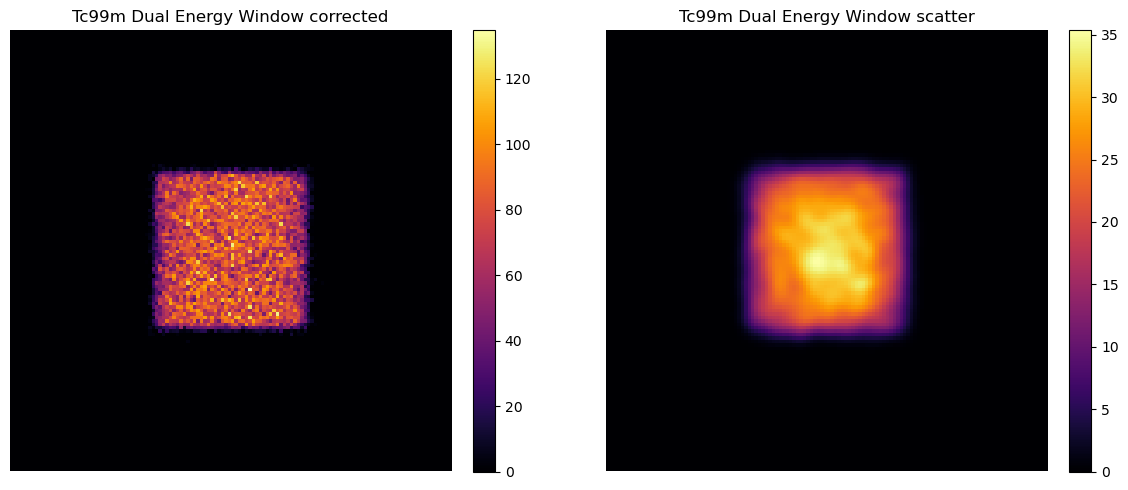

In [24]:
idx = (slice(None), 60, slice(None))
vmax = np.max(spect.AcquisitionData(str(pp_path)).as_array()[0,:])

utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(pp_path)).as_array()[0,:], spect.AcquisitionData(str(pp_path_noisy)).as_array()[0,:]],
    idx=idx,
    titles=["Tc99m 140keV no noise", "Tc99m 140keV with Poisson noise"],
    vmax=[vmax, vmax],
    vmin =[0, 0]
)

vmax = np.max(spect.AcquisitionData(str(sc_path)).as_array()[0,:])
utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(sc_path)).as_array()[0,:], spect.AcquisitionData(str(sc_path_noisy)).as_array()[0,:]],
    idx=idx,
    titles=["Tc99m Lower Scatter no noise", "Tc99m Lower Scatter with noise"],
    vmax=[vmax, vmax],
    vmin=[0, 0]
)

utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(dew_path)).as_array()[0,:], spect.AcquisitionData(str(dew_sc_path)).as_array()[0,:]],
    idx=idx,
    titles=["Tc99m Dual Energy Window corrected", "Tc99m Dual Energy Window scatter"]
)

In [26]:
window_lower = [187.2, 156.4, 229.36] # keV
window_upper = [228.8, 183.6, 258.64] # keV
scatter_orders = [0,] * len(window_upper)
time_per_proj = 10 #sec

config_file = Path("/home/jovyan/sirf-demo/.packages/Discovery670_lu177.yaml")

output_lu_dir = demo_path / "lu177_128" / "output"
output_lu_dir.mkdir(parents=True, exist_ok=True)

output_prefix = "lu177_simulation"

simind = StirSimindAdaptor(
    config_source=str(config_file),
    output_dir=str(output_lu_dir),
    output_prefix=output_prefix,
    photon_multiplier=0.01,
)


# Set source and attenuation map

simind.set_source(cyl_act_lu)
simind.set_mu_map(cyl_ctac_lu)

simind.add_config_value(25, np.sum(cyl_act_lu.as_array()) * time_per_proj)

# Set energy windows

simind.set_energy_windows(
    lower_bounds=window_lower,
    upper_bounds=window_upper,
    scatter_orders=scatter_orders,
)



# SIMIND runtime settings

# Lu-177 radionuclide data
simind.add_runtime_switch("FI", "lu177")

# Discovery 670 collimator.
# Your YAML contains "ge-megp" as text variable 1.
simind.add_runtime_switch("CC", "ge-megp")

# Random seed
simind.add_runtime_switch("RR", 12345)


# -------------------------------------------------------------------------
# Run SIMIND
# -------------------------------------------------------------------------

outputs = simind.run()



INFO: Running SIMIND: simind lu177_simulation lu177_simulation /NN:0.01/FI:lu177/CC:ge-megp/RR:12345/PX:0.4420000076293945


 



              SIMIND Monte Carlo Simulation Program    V8.0  
------------------------------------------------------------------------------
 Phantom S : h2o       Crystal...: nai       InputFile.: lu177_simulation  
 Phantom B : bone      BackScatt.: pmt       OutputFile: lu177_simulation  
 Collimator: pb_sb2    SourceRout: smap      SourceImg.: lu177_simulation_s
 Cover.....: al        ScoreRout.: scattwin  DensityImg: lu177_simulation_d
------------------------------------------------------------------------------
 PhotonEnergy.......: 208          lu177     PhotonsPerProj....: 364469         
 EnergyResolution...: 12           Spectra   Activity..........: 3147.3         
 MaxScatterOrder....: 3            ge-megp   DetectorLenght....: 20             
 DetectorWidth......: 27           SPECT     DetectorHeight....: 0.9525         
 UpperEneWindowTresh: 312          x-rays    Distance to det...: 11.979         
 LowerEneWindowTresh: 104          Random    ShiftSource X.....: 0

INFO: Converted 120 radii from orbit file lu177_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/icf_calculation/lu177_128/output/lu177_simulation_air_w1.h00 to /home/jovyan/sirf-demo/icf_calculation/lu177_128/output/lu177_simulation_air_w1.hs
INFO: Converted 120 radii from orbit file lu177_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/icf_calculation/lu177_128/output/lu177_simulation_air_w2.h00 to /home/jovyan/sirf-demo/icf_calculation/lu177_128/output/lu177_simulation_air_w2.hs
INFO: Converted 120 radii from orbit file lu177_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/icf_calculation/lu177_128/output/lu177_simulation_air_w3.h00 to /home/jovyan/sirf-demo/icf_calculation/lu177_128/output/lu177_simulation_air_w3.hs
INFO: Converted 120 radii from orbit file lu177_simulation.cor
INFO: Successfully converted /home/jovyan/sirf-demo/icf_calculation/lu177_128/output/lu177_simulation_sca_w1.h00 to /home/jovyan/sirf-demo/icf_calculat

------------------------------------------------------------------------------
 GENERAL DATA
 keV/channel........: 1                      CutoffEnergy......: 0              
 Photons/Bq.........: 0.2264                 StartingAngle.....: 0              
 CameraOffset X.....: 0                      CoverThickness....: 0.1            
 CameraOffset Y.....: 0                      BackscatterThickn.: 0              
 MatrixSize I.......: 128                    IntrinsicResolut..: 0.55           
 MatrixSize J.......: 128                    AcceptanceAngle...: 4.02754        
 Emission type......: 2                      Initial Weight....: 1955.01517     
 NN ScalingFactor...: 0.01                   Energy Channels...: 512            
                                                                              
 SPECT DATA
 RotationMode.......: 360                    Nr of Projections.: 120            
 RotationAngle......: 3                      Projection.[start]: 1              
 Orbit

## Add Poisson Noise and Perform Lu-177 Scatter Correction

The simulated Lu-177 projections are processed to produce realistic acquisition data for reconstruction.

In this step:

- **Poisson noise** is added independently to the photopeak and both scatter-window projections to model photon-counting statistics.
- The noisy projections are saved separately, preserving the original SIMIND simulation data.
- The **lower and upper scatter windows** are used to estimate the scatter contribution within the photopeak window.
- A **triple-energy window (TEW) scatter correction** is applied to the noisy projection data.

The resulting TEW scatter-corrected acquisition data are saved for use in the subsequent **Lu-177 SPECT image reconstruction**.

In [30]:
output_tc_dir = Path(str(demo_path / "lu177_128" / "output"))
output_prefix = "lu177_simulation"

pp_path = output_lu_dir / f"{output_prefix}_tot_w1.hs"
sc1_path = output_lu_dir / f"{output_prefix}_tot_w2.hs"
sc2_path = output_lu_dir / f"{output_prefix}_tot_w3.hs"

tomo_lu_dir = demo_path / "lu177_128" / "tomo"
tomo_lu_dir.mkdir(parents=True, exist_ok=True)

pp_path_noisy = tomo_lu_dir / f"{output_prefix}_em_noisy.hs"
sc1_path_noisy = tomo_lu_dir / f"{output_prefix}_sc1_noisy.hs"
sc2_path_noisy = tomo_lu_dir / f"{output_prefix}_sc2_noisy.hs"
tew_path = tomo_lu_dir / f"{output_prefix}_tew.hs"
tew_sc_path = tomo_lu_dir / f"{output_prefix}_tew_scatter.hs"

utils.acq_poisson_noise(
    hs_file=pp_path,
    save_path=pp_path_noisy
)

utils.acq_poisson_noise(
    hs_file=sc1_path,
    save_path=sc1_path_noisy
)

utils.acq_poisson_noise(
    hs_file=sc2_path,
    save_path=sc2_path_noisy
)

utils.scatter_correction(
    PP_hdr=str(pp_path_noisy),
    SC1_hdr=str(sc1_path_noisy),
    SC2_hdr=str(sc2_path_noisy),
    save_filepath=tew_path
)


Second Scatter Window present. Performing TEW...
Photopeak window width: 41.6
Scatter window 1 width: 27.2
Scatter window 2 width: 29.28
Tag !image duration (sec)[1] not found!
Scatter correction completed successfully!


(<sirf.STIR.AcquisitionData at 0x75b0e1acef90>,
 <sirf.STIR.AcquisitionData at 0x75b0d4933e60>)

(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': 'Lu177 Triple Energy Window corrected'}>,
        <Axes: title={'center': 'Lu177 Triple Energy Window scatter'}>],
       dtype=object))

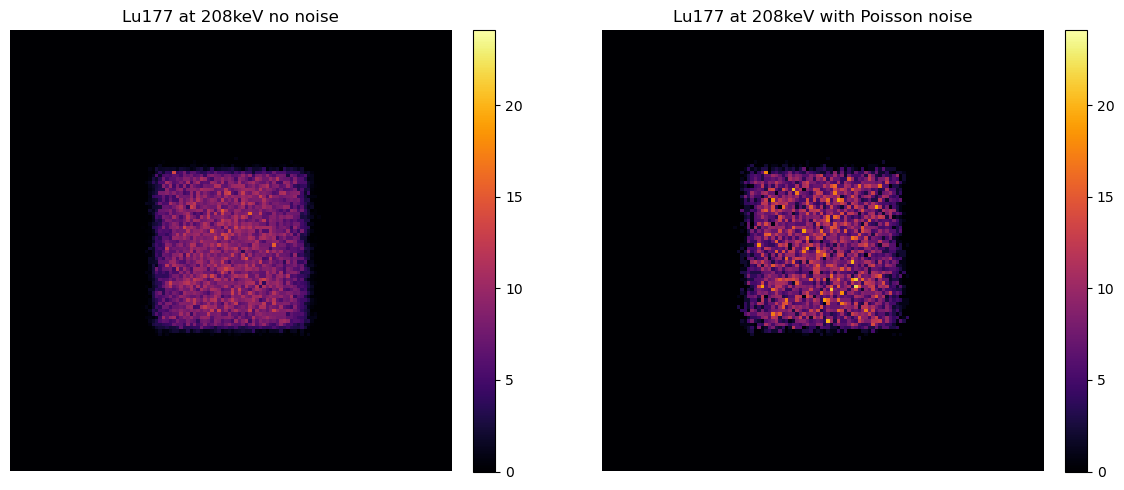

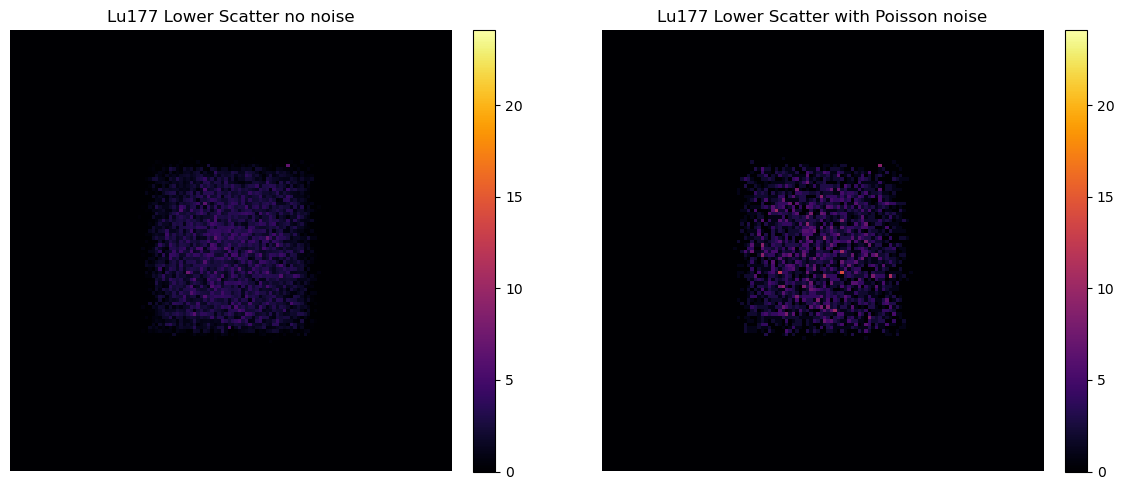

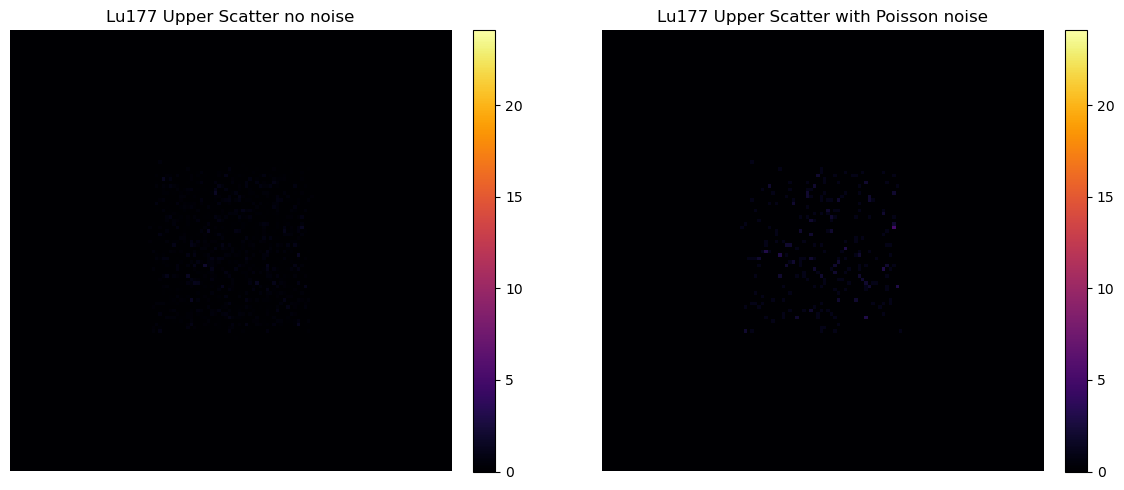

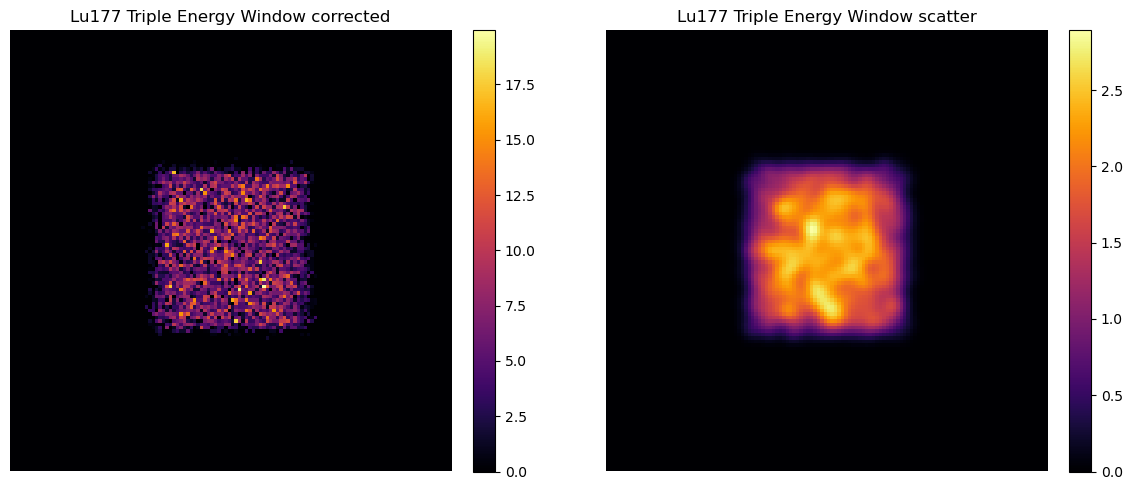

In [31]:
idx = (slice(None), 55, slice(None))
vmax = np.max(spect.AcquisitionData(str(pp_path)).as_array()[0,:])

utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(pp_path)).as_array()[0,:], spect.AcquisitionData(str(pp_path_noisy)).as_array()[0,:]],
    idx=idx,
    vmax=[vmax, vmax],
    vmin=[0, 0],
    titles=["Lu177 at 208keV no noise", "Lu177 at 208keV with Poisson noise"]
)

utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(sc1_path)).as_array()[0,:], spect.AcquisitionData(str(sc1_path_noisy)).as_array()[0,:]],
    idx=idx,
    vmax=[vmax, vmax],
    vmin=[0, 0],
    titles=["Lu177 Lower Scatter no noise", "Lu177 Lower Scatter with Poisson noise"]
)

utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(sc2_path)).as_array()[0,:], spect.AcquisitionData(str(sc2_path_noisy)).as_array()[0,:]],
    idx=idx,
    vmax=[vmax, vmax],
    vmin=[0, 0],
    titles=["Lu177 Upper Scatter no noise", "Lu177 Upper Scatter with Poisson noise"]
)

utils.display_arr(
    arr_3d=[spect.AcquisitionData(str(tew_path)).as_array()[0,:], spect.AcquisitionData(str(tew_sc_path)).as_array()[0,:]],
    idx=idx,
    titles=["Lu177 Triple Energy Window corrected", "Lu177 Triple Energy Window scatter"]
)